In [9]:
#The following code file will help to train the CNNBC Model as well as produce the bias corrected results for both training duration and the testing duration.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import gc


import os 
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "5"
import numpy as np

train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_train_24_06_1.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_train_24_06.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 


# def preprocess_data(data, label):
#     # Crop or resize input data to match expected shape
#     data = data[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)
    
#     # Crop or resize label data to match input spatial dimensions
#     label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

#     return data, label

# # Preprocess data
# data, label = preprocess_data(data, label)

# expanded_arr = np.expand_dims(data, axis=1)
# data = np.repeat(expanded_arr, 10, axis=1)
# expanded_arr1 = np.expand_dims(label, axis=1)
# label = np.repeat(expanded_arr1, 10, axis=1)

tx=np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_test_24_06.npy')
tsx=np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_test_24_06.npy')


def create_model():
  input_layer = layers.Input(shape=(10,32,32,1))
  C1 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9), activation='relu', padding='same', use_bias=True)(input_layer)
  C1 = tf.keras.layers.Dropout(0.2)(C1)
  C2 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)(C1)
  C2 = tf.keras.layers.Dropout(0.1)(C2)
  C3 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)(C2)
  C4 = tf.keras.layers.Conv3D(filters=64, kernel_size = (9, 9,9),activation='relu', padding='same', use_bias=True)((C3+input_layer)*0.5)
  C4 = tf.keras.layers.Dropout(0.2)(C4)
  C5 = tf.keras.layers.Conv3D(filters=32, kernel_size = (3, 3,3), activation='relu', padding='same', use_bias=True)((C1+C4)*0.5)
  C5 = tf.keras.layers.Dropout(0.1)(C5)
  C6 = tf.keras.layers.Conv3D(filters=1, kernel_size = (5, 5,5), activation='linear', padding='same', use_bias=True)((C2+C5)*0.5)
  output_layer= tf.keras.layers.Conv3D(filters=1, kernel_size = (10,1,1), strides=(10,1,1), activation='relu', padding='same', use_bias=True)(C6)
  model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
  model.compile(optimizer='adam', loss='mean_squared_error',metrics='accuracy')
  model.summary()
  #Set EarlyStopping Criteria
  earlystop=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=50,
    verbose=0,
    mode='min',
    baseline=None,
    restore_best_weights=True
  )
  checkpoint=tf.keras.callbacks.ModelCheckpoint(
    filepath="checkcnnmodel.keras",
    monitor='val_loss',
    verbose=1,
    mode='min',
    save_best_only= True,
    )
  return model,checkpoint,earlystop

model_CNNBC,checkpoint,earlystop = create_model()
model_CNNBC.fit(data,label,batch_size=16,epochs=500, verbose=2, validation_split=0.20,callbacks=[checkpoint, earlystop])
model_CNNBC.save("my_cnnmodel.h5", include_optimizer=True)
tr_result=model_CNNBC.predict(tx)
ts_result=model_CNNBC.predict(tsx)

  # rtrain=np.reshape(tr_result,(1032,32, 32))
  # ## rtest : result of test data
  # rtest=np.reshape(ts_result,(258, 32, 32))
  # #ltrain = level data 
  # ltrain=np.reshape(trainy,(1032, 32, 32))
  # #ltest : level data for test 
  # ltest=np.reshape(testy,(258, 32, 32))
  
  #btrain=np.reshape(trainb,(1032, 32, 32))
  #btest=np.reshape(testb,(258, 32, 32))

#   np.save(path+str(i)+".npy",rtrain)
#   np.save(path+str(i)+".npy",rtest)
#   np.save(path+str(i)+".npy",ltrain)
#   np.save(path+str(i)+".npy",ltest)
#   #np.save(path+"/Result/tr_bias"+str(i)+".npy",btrain)
#   #np.save(path+"/Result/ts_bias"+str(i)+".npy",btest)

#   del model_CNNBC,checkpoint,earlystop
#   del tr_result,ts_result
#   del tx,ty,tsx
#   del trainx,trainy,trainb,testx,testy,testb
#   del tr_year,ts_year
#   del start_index_tr,end_index_tr,start_index_ts,end_index_ts
#   del rtrain,rtest,ltrain,ltest,btrain,btest
gc.collect()



Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d_8 (Conv3D)               (None, 10, 32, 32, 6 46720       input_3[0][0]                    
__________________________________________________________________________________________________
dropout_4 (Dropout)             (None, 10, 32, 32, 6 0           conv3d_8[0][0]                   
__________________________________________________________________________________________________
conv3d_9 (Conv3D)               (None, 10, 32, 32, 3 55328       dropout_4[0][0]                  
____________________________________________________________________________________________

KeyboardInterrupt: 

In [3]:
max_val = np.max(data)
min_val = np.min(data)
print(max_val,min_val)

2e+20 0.0


In [9]:
import numpy as np



# Find the maximum value in the array
max_value = np.max(data)

# Find the index (or indices) of the maximum value
max_indices = np.where(data == max_value)

# Replace the maximum value(s) with zero
data[max_indices] = 0

print(arr)


TypeError: 'int' object does not support item assignment

In [17]:
train_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")

data=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy") # Load the input samples for the model(biased data samples) 
label=np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/pr_rainfall.npy") # Load the labels(observation samples)
#biasdata=np.load("./Data/biasdata100.npy") 


def preprocess_data(data, label):
    # Crop or resize input data to match expected shape
    data = data[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 10, 32, 32, 1)
    
    # Crop or resize label data to match input spatial dimensions
    label = label[:, :32, :32, np.newaxis]  # Crop or resize to match (None, 32, 32, 1)

    return data, label

# Preprocess data
data, label = preprocess_data(data, label)

expanded_arr = np.expand_dims(data, axis=1)
data = np.repeat(expanded_arr, 10, axis=1)
expanded_arr = np.expand_dims(label, axis=1)
data = np.repeat(expanded_arr, 10, axis=1)

In [38]:
lat_min, lat_max = 6.0, 37.0
lon_min, lon_max = 68.0, 97.0
mask = data > lat_min &

(1560, 32, 32)

In [ ]:
# Assuming `data` is your real dataset with shape (years, lat, lon)
import numpy as np
data= np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/CFS_0rainfall.npy')
climatology = data.mean(axis=0)

# Save the climatology to a file if needed
np.save('climatology.npy', climatology)

print("Climatology:\n", climatology)


Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d_14 (Conv3D)              (None, 10, 32, 32, 6 46720       input_3[0][0]                    
__________________________________________________________________________________________________
dropout_8 (Dropout)             (None, 10, 32, 32, 6 0           conv3d_14[0][0]                  
__________________________________________________________________________________________________
conv3d_15 (Conv3D)              (None, 10, 32, 32, 3 55328       dropout_8[0][0]                  
____________________________________________________________________________________________

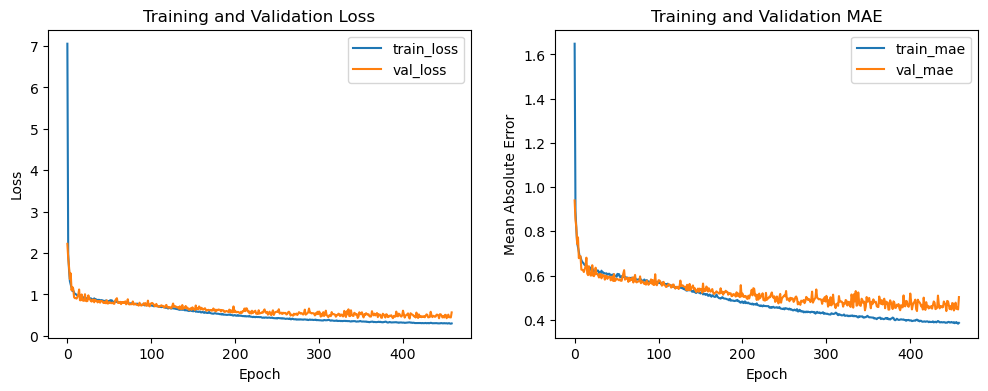

ValueError: x and y must have the same length.

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import gc
import os
from scipy.stats import pearsonr

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "5"

# Load data
train_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")
data = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_train_24_06_1.npy")
label = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_train_24_06.npy")
tx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_test_24_06.npy')
tsx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_test_24_06.npy')

def create_model():
    input_layer = layers.Input(shape=(10, 32, 32, 1))
    C1 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)(input_layer)
    C1 = tf.keras.layers.Dropout(0.2)(C1)
    C2 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)(C1)
    C2 = tf.keras.layers.Dropout(0.1)(C2)
    C3 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)(C2)
    C4 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)((C3 + input_layer) * 0.5)
    C4 = tf.keras.layers.Dropout(0.2)(C4)
    C5 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)((C1 + C4) * 0.5)
    C5 = tf.keras.layers.Dropout(0.1)(C5)
    C6 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)((C2 + C5) * 0.5)
    output_layer = tf.keras.layers.Conv3D(filters=1, kernel_size=(10, 1, 1), strides=(10, 1, 1), activation='relu', padding='same', use_bias=True)(C6)
    
    model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
    model.summary()
    
    # Set EarlyStopping Criteria
    earlystop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=50,
        verbose=0,
        mode='min',
        baseline=None,
        restore_best_weights=True
    )
    
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="checkcnnmodel.keras",
        monitor='val_loss',
        verbose=1,
        mode='min',
        save_best_only=True,
    )
    
    return model, checkpoint, earlystop

model_CNNBC, checkpoint, earlystop = create_model()
history = model_CNNBC.fit(data, label, batch_size=16, epochs=500, verbose=2, validation_split=0.20, callbacks=[checkpoint, earlystop])
model_CNNBC.save("my_cnnmodel.h5", include_optimizer=True)

# Predict results
tr_result = model_CNNBC.predict(tx)
ts_result = model_CNNBC.predict(tsx)

# Plotting the training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)

# Save results
# np.save("tr_result.npy", tr_result)
# np.save("ts_result.npy", ts_result)

# Correlation calculation and plotting
def plot_correlation(predicted, actual, title):
    predicted_flat = predicted.flatten()
    actual_flat = actual.flatten()
    correlation, _ = pearsonr(predicted_flat, actual_flat)
    plt.figure(figsize=(6, 6))
    plt.scatter(actual_flat, predicted_flat, alpha=0.5)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{title}\nCorrelation: {correlation:.2f}')
    plt.grid(True)
    plt.show()

# Calculate and plot correlation for training and test results
plot_correlation(tr_result, label, 'Training Data Correlation')
plot_correlation(ts_result, tsx, 'Test Data Correlation')

gc.collect()


In [16]:
plt.plot(history.history['loss'], label='train_loss')

IndentationError: expected an indented block (2375445572.py, line 32)

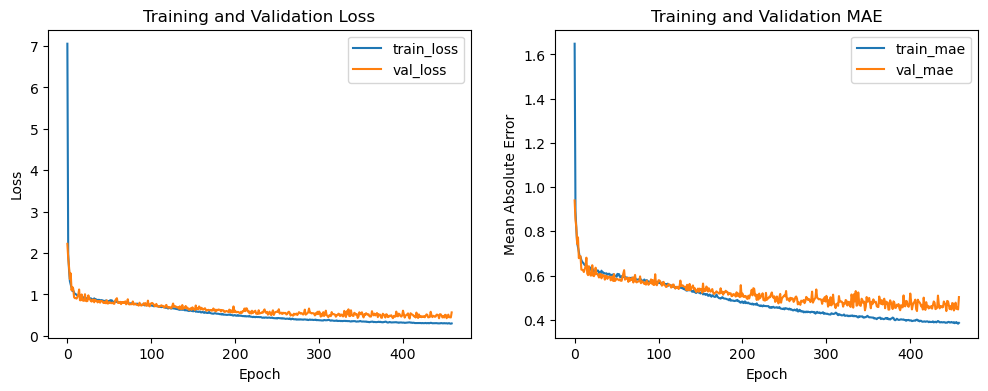

In [14]:
plot_history(history)

2024-06-24 17:57:59.410502: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


Shape of training data: (1032, 10, 32, 32, 1)
Shape of training labels: (1032, 10, 32, 32, 1)
Shape of test data: (258, 10, 32, 32, 1)
Shape of test labels: (258, 10, 32, 32, 1)


2024-06-24 17:58:00.822711: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2024-06-24 17:58:00.914232: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:8b:00.0 name: NVIDIA A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2024-06-24 17:58:00.914276: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2024-06-24 17:58:00.925020: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2024-06-24 17:58:00.925060: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11
2024-06-24 17:58:00.927601: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcufft.

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, 10, 32, 32, 6 46720       input_1[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 10, 32, 32, 6 0           conv3d[0][0]                     
__________________________________________________________________________________________________
conv3d_1 (Conv3D)               (None, 10, 32, 32, 3 55328       dropout[0][0]                    
______________________________________________________________________________________________

2024-06-24 17:58:01.842367: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2024-06-24 17:58:01.846414: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2794960000 Hz


Epoch 1/500


2024-06-24 17:58:03.443472: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudnn.so.8
2024-06-24 17:58:04.331230: I tensorflow/stream_executor/cuda/cuda_dnn.cc:359] Loaded cuDNN version 8204
2024-06-24 17:58:05.657324: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2024-06-24 17:58:06.347924: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11


52/52 - 6s - loss: 10.6024 - mean_absolute_error: 2.0874 - val_loss: 3.6165 - val_mean_absolute_error: 1.2375

Epoch 00001: val_loss improved from inf to 3.61652, saving model to checkcnnmodel.keras
Epoch 2/500
52/52 - 1s - loss: 2.9751 - mean_absolute_error: 1.1065 - val_loss: 2.3289 - val_mean_absolute_error: 0.9816

Epoch 00002: val_loss improved from 3.61652 to 2.32887, saving model to checkcnnmodel.keras
Epoch 3/500
52/52 - 1s - loss: 2.3048 - mean_absolute_error: 0.9659 - val_loss: 2.1456 - val_mean_absolute_error: 0.8962

Epoch 00003: val_loss improved from 2.32887 to 2.14562, saving model to checkcnnmodel.keras
Epoch 4/500
52/52 - 1s - loss: 1.8735 - mean_absolute_error: 0.8771 - val_loss: 1.6615 - val_mean_absolute_error: 0.8113

Epoch 00004: val_loss improved from 2.14562 to 1.66152, saving model to checkcnnmodel.keras
Epoch 5/500
52/52 - 1s - loss: 1.6304 - mean_absolute_error: 0.8254 - val_loss: 1.3960 - val_mean_absolute_error: 0.7565

Epoch 00005: val_loss improved from 1

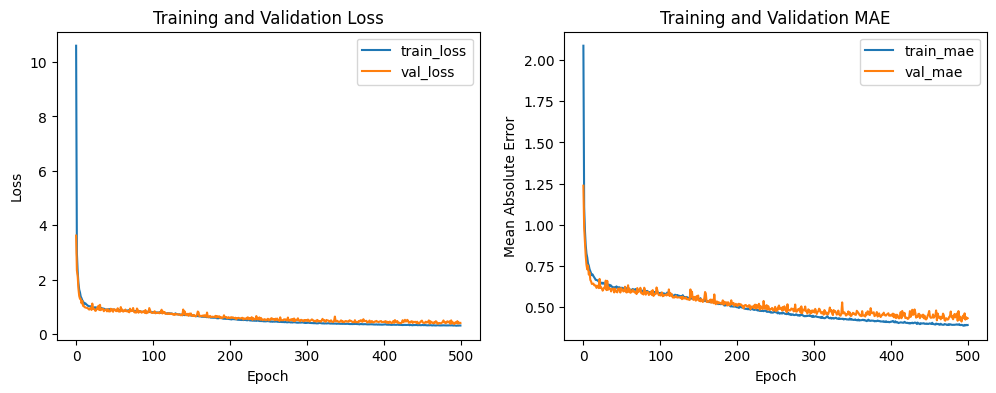

9773

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import gc
import os

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"]= "5"

# Load data
train_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")
data = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_train_24_06_1.npy")
label = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_train_24_06.npy")
tx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_test_24_06.npy')
tsx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_test_24_06.npy')

# Print shapes for debugging
print("Shape of training data:", data.shape)
print("Shape of training labels:", label.shape)
print("Shape of test data:", tx.shape)
print("Shape of test labels:", tsx.shape)

def create_model():
    input_layer = layers.Input(shape=(10, 32, 32, 1))
    C1 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)(input_layer)
    C1 = tf.keras.layers.Dropout(0.2)(C1)
    C2 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)(C1)
    C2 = tf.keras.layers.Dropout(0.1)(C2)
    C3 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)(C2)
    C4 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)((C3 + input_layer) * 0.5)
    C4 = tf.keras.layers.Dropout(0.2)(C4)
    C5 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)((C1 + C4) * 0.5)
    C5 = tf.keras.layers.Dropout(0.1)(C5)
    C6 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)((C2 + C5) * 0.5)
    output_layer = tf.keras.layers.Conv3D(filters=1, kernel_size=(10, 1, 1), strides=(10, 1, 1), activation='relu', padding='same', use_bias=True)(C6)
    
    model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
    model.summary()
    
    # Set EarlyStopping Criteria
    earlystop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=50,
        verbose=0,
        mode='min',
        baseline=None,
        restore_best_weights=True
    )
    
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="checkcnnmodel.keras",
        monitor='val_loss',
        verbose=1,
        mode='min',
        save_best_only=True,
    )
    
    return model, checkpoint, earlystop

model_CNNBC, checkpoint, earlystop = create_model()
history = model_CNNBC.fit(data, label, batch_size=16, epochs=500, verbose=2, validation_split=0.20, callbacks=[checkpoint, earlystop])
model_CNNBC.save("my_cnnmodel.h5", include_optimizer=True)

# Predict results
tr_result = model_CNNBC.predict(data)
ts_result = model_CNNBC.predict(tx)

# Print shapes of predictions for debugging
print("Shape of training predictions:", tr_result.shape)
print("Shape of test predictions:", ts_result.shape)

# Plotting the training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)

# Save results
# np.save("tr_result.npy", tr_result)
# np.save("ts_result.npy", ts_result)

gc.collect()


Shape of training data: (1032, 10, 32, 32, 1)
Shape of training labels: (1032, 10, 32, 32, 1)
Shape of test data: (258, 10, 32, 32, 1)
Shape of test labels: (258, 10, 32, 32, 1)
Model: "model_5"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_7 (InputLayer)            [(None, 10, 32, 32,  0                                            
__________________________________________________________________________________________________
conv3d_36 (Conv3D)              (None, 10, 32, 32, 6 46720       input_7[0][0]                    
__________________________________________________________________________________________________
dropout_20 (Dropout)            (None, 10, 32, 32, 6 0           conv3d_36[0][0]                  
__________________________________________________________________________________________________
conv3d_37 (Co

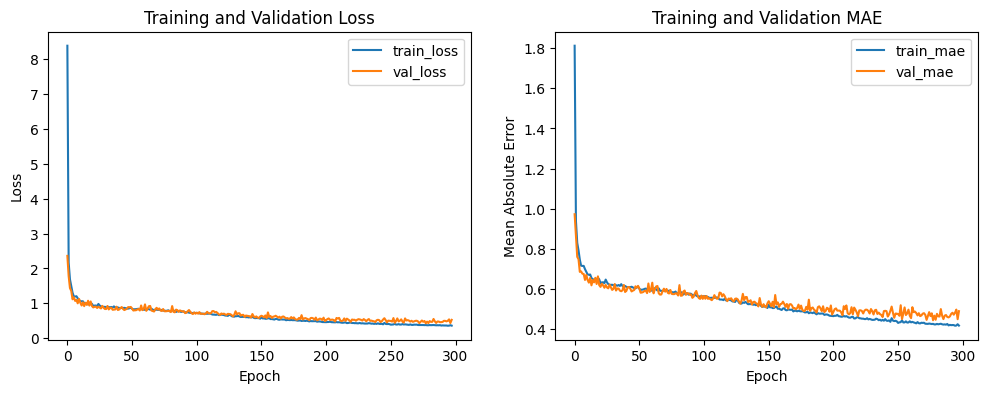

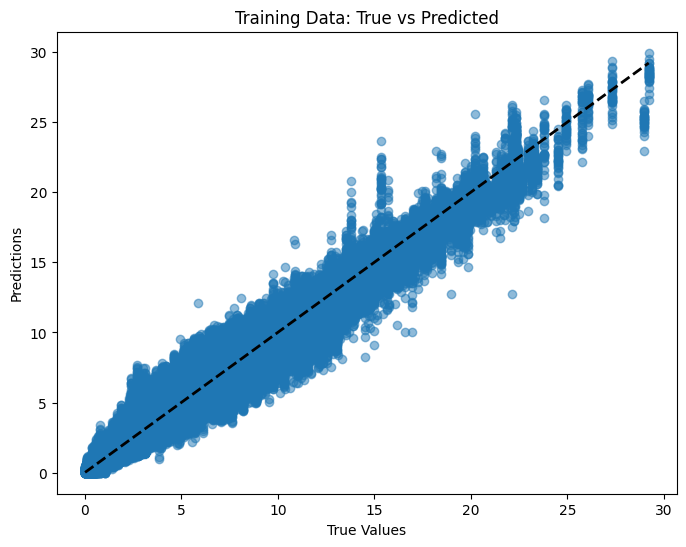

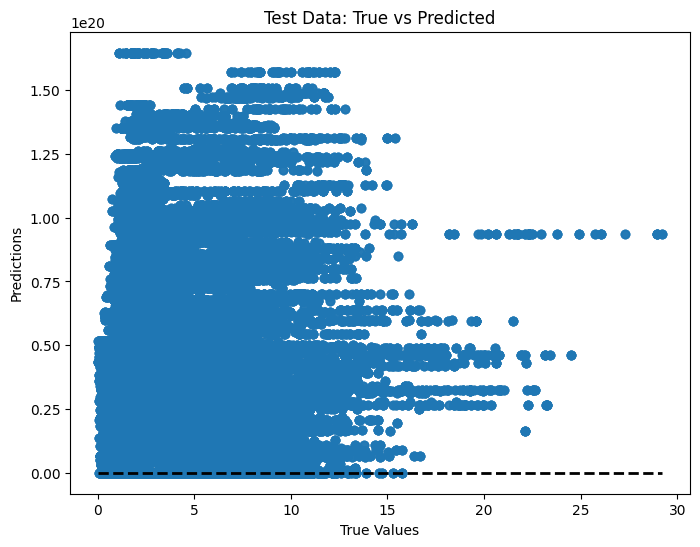

39806

In [34]:
#25-06-2024 to check correlation

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import gc
import os

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

# Load data
train_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/train_year.npy")
test_year = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/test_year.npy")
data = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_train_24_06_1.npy")
label = np.load("/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_train_24_06.npy")
tx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/X_test_24_06.npy')
tsx = np.load('/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/npy_files/y_test_24_06.npy')

# Print shapes for debugging
print("Shape of training data:", data.shape)
print("Shape of training labels:", label.shape)
print("Shape of test data:", tx.shape)
print("Shape of test labels:", tsx.shape)

def create_model():
    input_layer = layers.Input(shape=(10, 32, 32, 1))
    C1 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)(input_layer)
    C1 = tf.keras.layers.Dropout(0.2)(C1)
    C2 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)(C1)
    C2 = tf.keras.layers.Dropout(0.1)(C2)
    C3 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)(C2)
    C4 = tf.keras.layers.Conv3D(filters=64, kernel_size=(9, 9, 9), activation='relu', padding='same', use_bias=True)((C3 + input_layer) * 0.5)
    C4 = tf.keras.layers.Dropout(0.2)(C4)
    C5 = tf.keras.layers.Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu', padding='same', use_bias=True)((C1 + C4) * 0.5)
    C5 = tf.keras.layers.Dropout(0.1)(C5)
    C6 = tf.keras.layers.Conv3D(filters=1, kernel_size=(5, 5, 5), activation='linear', padding='same', use_bias=True)((C2 + C5) * 0.5)
    output_layer = tf.keras.layers.Conv3D(filters=1, kernel_size=(10, 1, 1), strides=(10, 1, 1), activation='relu', padding='same', use_bias=True)(C6)
    
    model = tf.keras.Model(inputs=[input_layer], outputs=[output_layer])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
    model.summary()
    
    # Set EarlyStopping Criteria
    earlystop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=0,
        patience=20,
        verbose=0,
        mode='min',
        baseline=None,
        restore_best_weights=True
    )
    
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="checkcnnmodel.keras",
        monitor='val_loss',
        verbose=1,
        mode='min',
        save_best_only=True,
    )
    
    return model, checkpoint, earlystop

model_CNNBC, checkpoint, earlystop = create_model()
history = model_CNNBC.fit(data, label, batch_size=16, epochs=500, verbose=2, validation_split=0.20, callbacks=[checkpoint, earlystop])
model_CNNBC.save("my_cnnmodel.h5", include_optimizer=True)

# Predict results
tr_result = model_CNNBC.predict(data)
ts_result = model_CNNBC.predict(tx)

# Print shapes of predictions for debugging
print("Shape of training predictions:", tr_result.shape)
print("Shape of test predictions:", ts_result.shape)

tr_result=np.reshape(tr_result,(1032,32,32))
ts_result=np.reshape(ts_result,(258,32,32))
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.delete(label, 1, axis=1)
label=np.reshape(label,(1032,32,32))
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.delete(tsx, 1, axis=1)
tsx=np.reshape(tsx,(258,32,32))

# Flatten the predictions and labels to calculate the correlation
tr_result_flat = tr_result.flatten()
label_flat = label.flatten()
ts_result_flat = ts_result.flatten()
tsx_flat = tsx.flatten()

# Calculate correlation coefficients
train_correlation = np.corrcoef(tr_result_flat, label_flat)[0, 1]
test_correlation = np.corrcoef(ts_result_flat, tsx_flat)[0, 1]

print(f'Training correlation coefficient: {train_correlation}')
print(f'Test correlation coefficient: {test_correlation}')

# Plotting the training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mean_absolute_error'], label='train_mae')
    plt.plot(history.history['val_mean_absolute_error'], label='val_mae')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title('Training and Validation MAE')
    plt.legend()

    plt.show()

plot_history(history)

# Scatter plot of predictions vs. true values
def plot_predictions(true_values, predictions, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(true_values, predictions, alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(title)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.show()

plot_predictions(label_flat, tr_result_flat, 'Training Data: True vs Predicted')
plot_predictions(tsx_flat, ts_result_flat, 'Test Data: True vs Predicted')

gc.collect()


In [36]:
conda install -c conda-forge ffmpeg


done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 22.9.0
  latest version: 24.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/hpcs_rnd/anaconda3/envs/Yatendra_Env

  added / updated specs:
    - ffmpeg


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    gmp-6.3.0                  |       hac33072_2         449 KB  conda-forge
    libopus-1.3.1              |       h7f98852_1         255 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         704 KB

The following NEW packages will be INSTALLED:

  ffmpeg             pkgs/main/linux-64::ffmpeg-4.2.2-h20bf706_0 None
  freetype           conda-forge/linux-64::freetype-2.12.1-h267a509_2 None
  gmp                conda-forg

/tmp/ipykernel_93242/4195927650.py:57: UserWarning: frames=<generator object <genexpr> at 0x7f83e559f6d0> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, update_plot, frames=frames, blit=True)


Video has been saved successfully.


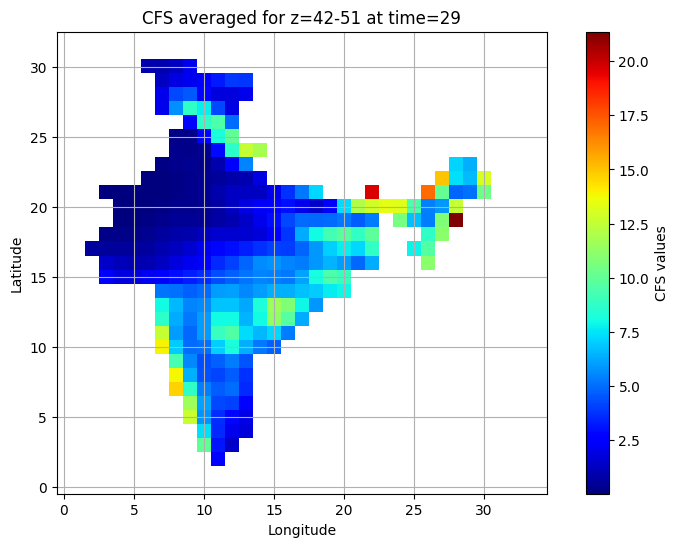

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Load the NetCDF file
data = xr.open_dataset(r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction/Subodh_Data/JJASavg_IMDgrid_CFSrain_ens-wise.nc", decode_times=False)

# Extract the variable 'cfs'
cfs_data = data['cfs']

# Create a directory to save the video
output_dir = r"/home/hpcs_rnd/Yatendra_IITKgp/bias_correction"
os.makedirs(output_dir, exist_ok=True)

# Define the number of slices for z
z_slices = 10
total_images_z = cfs_data.sizes['z'] - z_slices + 1
total_images_t = cfs_data.sizes['time']

# Prepare the figure for plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Initial plot
initial_data = cfs_data.isel(time=0, z=slice(0, z_slices)).mean(dim='z')
im = ax.imshow(initial_data, origin='lower', cmap='jet')
cbar = fig.colorbar(im, ax=ax, label='CFS values')

def update_plot(frame):
    t_index, z_start = frame
    z_end = z_start + z_slices
    
    # Extract the data for plotting
    cfs_slice = cfs_data.isel(time=t_index, z=slice(z_start, z_end)).mean(dim='z')
    
    # Update the image data
    im.set_data(cfs_slice)
    
    # Update the colorbar
    im.set_clim(vmin=float(cfs_slice.min()), vmax=float(cfs_slice.max()))
    cbar.update_normal(im)
    
    ax.set_title(f'CFS averaged for z={z_start}-{z_end-1} at time={t_index}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True)
    
    return im,

# Generate the frames
frames = ((t, z) for t in range(total_images_t) for z in range(total_images_z))

# Set up the animation writer
Writer = FFMpegWriter(fps=5, metadata=dict(artist='Me'), bitrate=1800)

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=frames, blit=True)

# Save the video
video_path = os.path.join(output_dir, "CFS_video.mp4")
anim.save(video_path, writer=Writer)

print("Video has been saved successfully.")
